In this notebook we will cover some of the basic strategies to perform error mitigation for gate errors.

As an example we will try to correct errors on quantum circuits designed to approximate the dynamical evolution of a system with $n=2$ spins initialized in the state

$$\rvert\Psi(0)\rangle = \rvert10\rangle$$

and interacting with the following Ising Hamiltonian

$$H = -X_0X_1 + Z_0 + Z_1$$

The scheme should be then reasonably easy to generalize to simulations on larger systems.

### Exact evolution with numpy

We first perform the exact evolution using numpy as a way to have a reference calculation to benchmark our implementation

In [1]:
# let's code the ideal circuit in numpy first
import numpy as np

# we start defining all the Pauli observables
I = np.eye(2)
X = np.array([[0,1],[1,0]],dtype=complex)
Y = np.array([[0,-1.j],[1.j,0]],dtype=complex)
Z = np.array([[1,0],[0,-1]],dtype=complex)
# and now all possible two qubit observables
## NOTE: qiskit uses an ordering that goes left to right, we will do the same here
X_1 = np.kron(X,I); Y_1 = np.kron(Y,I); Z_1 = np.kron(Z,I)
X_0 = np.kron(I,X); Y_0 = np.kron(I,Y); Z_0 = np.kron(I,Z)
X_0X_1 = np.kron(X,X); Y_0X_1 = np.kron(X,Y); Z_0X_1 = np.kron(X,Z)
X_0Y_1 = np.kron(Y,X); Y_0Y_1 = np.kron(Y,Y); Z_0Y_1 = np.kron(Y,Z)
X_0Z_1 = np.kron(Z,X); Y_0Z_1 = np.kron(Z,Y); Z_0Z_1 = np.kron(Z,Z)

# these are the computational states
zero_state=np.array([1,0])
one_state=np.array([0,1])
# note the ordering convention to comply with the one in qiskit
initial_state = np.kron(zero_state,one_state)

In [2]:
import scipy as sp
## hamiltonian operator
ham = -X_0X_1+Z_0+Z_1
## exact evolution
tmax = 5*np.pi
times=np.linspace(0,tmax,100)
##
z0_oft = np.zeros(len(times))
z1_oft = np.zeros(len(times))
for tidx in range(len(times)):
    psit_now = sp.linalg.expm(-1.j*times[tidx]*ham)@initial_state
    z0_oft[tidx] = np.real(np.vdot(psit_now,Z_0@psit_now))
    z1_oft[tidx] = np.real(np.vdot(psit_now,Z_1@psit_now))

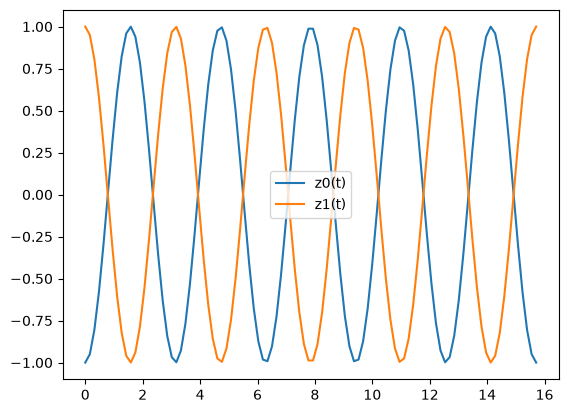

In [3]:
import matplotlib.pyplot as plt
plt.plot(times,z0_oft,label="z0(t)")
plt.plot(times,z1_oft,label="z1(t)")
plt.legend()
plt.show()

### Trotter evolution with numpy

We now implement a second order Trotter decomposition of the time evolution with a fixed time step

In [4]:
tstep = 0.5
expXX = sp.linalg.expm(tstep*1.j*X_0X_1)
expZ_half = sp.linalg.expm(-tstep*0.5j*(Z_0+Z_1))
trott_step = expZ_half@expXX@expZ_half
nsteps = int(tmax/tstep)
##
z0_oft_trott = np.zeros(nsteps)
z1_oft_trott = np.zeros(nsteps)
psit_now = initial_state
for tidx in range(nsteps):
    # measure current expectation values
    z0_oft_trott[tidx] = np.real(np.vdot(psit_now,Z_0@psit_now))
    z1_oft_trott[tidx] = np.real(np.vdot(psit_now,Z_1@psit_now))
    # make a step
    psit_now = trott_step@psit_now

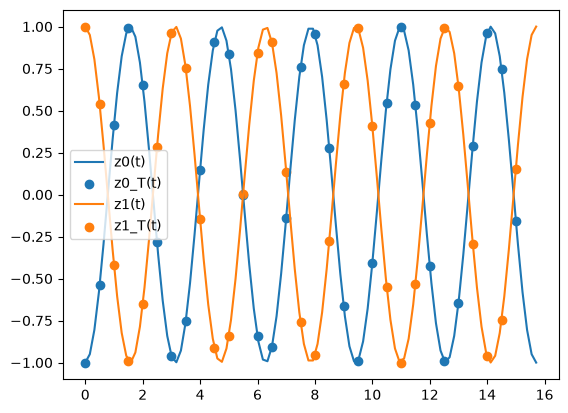

In [5]:
plt.plot(times,z0_oft,label="z0(t)")
plt.scatter(tstep*np.arange(nsteps),z0_oft_trott,label="z0_T(t)")
plt.plot(times,z1_oft,label="z1(t)")
plt.scatter(tstep*np.arange(nsteps),z1_oft_trott,label="z1_T(t)")
plt.legend()
plt.show()

The agreement is remarkable:

- why is this so good?
- does it matter we are doing a second-order approximation? What would've changed if we did it first-order?
- do you expect this great agreement to also hold for larger systems?

In [6]:
cxxz = X_0X_1@(Z_0+Z_1)-(Z_0+Z_1)@X_0X_1
cxxz

array([[ 0.+0.j,  0.+0.j,  0.+0.j, -4.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 4.+0.j,  0.+0.j,  0.+0.j,  0.+0.j]])

### Quantum circuit implementation

It is now time to start implementing the algorithm as a quantum circuit. We will make a simple 2 qubit backend as a target device

In [7]:
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2
# Generate a 2-qubit simulated backend
my_coupling_map = [(0, 1)] 
fake_2qubits = GenericBackendV2(
    num_qubits=2,
    coupling_map=my_coupling_map,
    basis_gates=["id", "rz", "sx", "x", "cz"],
    seed=42 # set a fixed seed for PRNG
)

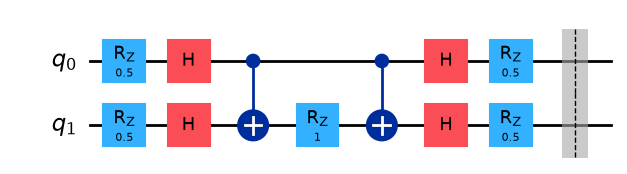

In [8]:
from qiskit import QuantumCircuit

## statevector simulation
state_prep_c = QuantumCircuit(2)
state_prep_c.x(0)

## Trotter step
trott_step_c = QuantumCircuit(2)
## z evolution for half step
trott_step_c.rz(tstep,[0,1])
## xx evolution for full step
trott_step_c.h([0,1])
trott_step_c.cx(0,1)
trott_step_c.rz(2*tstep,1)
trott_step_c.cx(0,1)
trott_step_c.h([0,1])
## z evolution for half step
trott_step_c.rz(tstep,[0,1])
## barrier to prevent unwanted optimizations
trott_step_c.barrier()

trott_step_c.draw('mpl')

In [9]:
circuits = []
circuit_now = state_prep_c.copy()
for steps in range(nsteps):
    circuits.append(circuit_now.copy())
    circuit_now.append(trott_step_c,[0,1])

Let's test the circuit with a statevector simulator first.

In [10]:
from qiskit_aer import AerSimulator
from qiskit import transpile

# transpile for this target
transpiled_circuits_sv = []
for circ in circuits:
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=0,
                                initial_layout=[0,1]
                    )
    transpiled_circuits_sv.append(transpiled)

In [11]:
# run circuits and extract expectation values
sim_statevector = AerSimulator(method='statevector')
z0_sv = np.zeros(len(transpiled_circuits_sv))
z1_sv = np.zeros(len(transpiled_circuits_sv))
for idx,circ in enumerate(transpiled_circuits_sv):
    circ.save_statevector()
    job_sv = sim_statevector.run(circ)
    result_sv = job_sv.result()
    outputstate_sv = result_sv.get_statevector(circ, decimals=8)
    npstate = np.array(outputstate_sv.data.tolist())
    z0_sv[idx] = np.real(np.vdot(npstate,Z_0@npstate))
    z1_sv[idx] = np.real(np.vdot(npstate,Z_1@npstate))

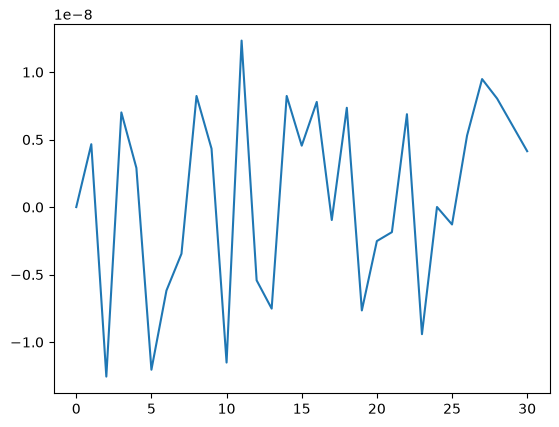

In [12]:
## plot differences in expectation values
plt.plot(z0_sv-z0_oft_trott)

### Noise simulator

We first generate a simple noise model with typical parameters for our fake backend

In [13]:
noise_model = NoiseModel.from_backend(fake_2qubits)

In [14]:
print(noise_model)

NoiseModel:
  Basis gates: ['cz', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['sx', 'measure', 'cz', 'x', 'id']
  Qubits with noise: [0, 1]
  Specific qubit errors: [('id', (0,)), ('id', (1,)), ('sx', (0,)), ('sx', (1,)), ('x', (0,)), ('x', (1,)), ('cz', (0, 1)), ('measure', (0,)), ('measure', (1,))]


We can now prepare for a sampler simulation with a standard noise model

In [15]:
sim_noisy = AerSimulator(noise_model=noise_model,target=fake_2qubits)

We start as always with two circuits for RO calibration

In [16]:
cal_circuits_simple = []
## first one for the 00 string
cal_circ_00 = QuantumCircuit(2)
cal_circ_00.measure_all()
cal_circuits_simple.append(cal_circ_00)
## last one for the 11 string
cal_circ_11 = QuantumCircuit(2)
cal_circ_11.x(0)
cal_circ_11.x(1)
cal_circ_11.measure_all()
cal_circuits_simple.append(cal_circ_11)

And now transpile everything, adding measurement to the Trotter evolution

In [17]:
transpiled_circuits = []
for circ in cal_circuits_simple:
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=0,
                                initial_layout=[0,1]
                    )
    transpiled_circuits.append(transpiled)
for circ in circuits:
    # add final measurements in the computational basis
    ## NOTE: this modifies original circuit
    circ.measure_all()
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=1,
                                initial_layout=[0,1]
                    )
    transpiled_circuits.append(transpiled)

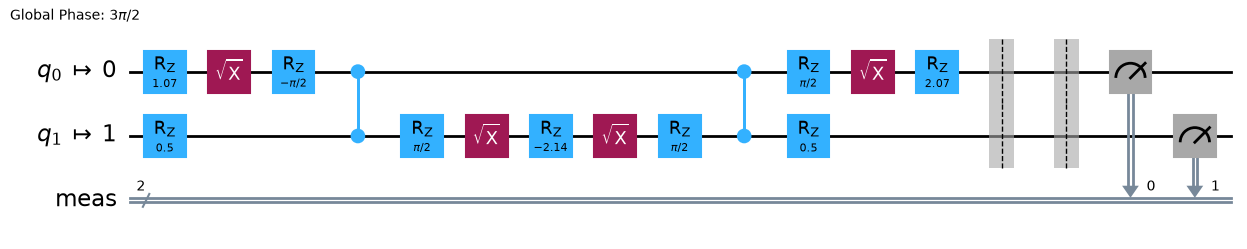

In [18]:
transpiled_circuits[3].draw('mpl')

In [19]:
noise_job = sim_noisy.run(transpiled_circuits,shots=100000,seed_simulator=21)
counts_noise = noise_job.result().get_counts()

Let's first look at the results without any error mitigation. We first define two functions to extract expectation values from counts

In [20]:
def exp_err_from_counts(input_counts, bits_for_observable):
    average_obs = 0.0
    tot_counts = 0
    for cc in input_counts:
        ## convert the measured bit-string into a list of numerical values
        int_bit_string = [int(bb) for bb in cc]
        ## compute the sum of bits (note the ordering convention)
        num_qubits = len(int_bit_string)
        exp_sum = sum([int_bit_string[num_qubits-1-bit] for bit in bits_for_observable])
        ## convert this into the corresponding value
        value = (-1)**exp_sum
        ## and accumulate the result by multiplying the number of counts
        average_obs += input_counts[cc]*value
        ## together with the cumulative number of counts
        tot_counts += input_counts[cc]
    ## we finish by dividing by the total number of counts
    average_obs /= tot_counts

    ## we now estimate the statistical error with the variance
    err_obs = np.sqrt((1-average_obs**2)/(tot_counts-1))
    return average_obs, err_obs

def prob_and_err_from_counts(input_counts, bits_for_observable):
    tot_counts = sum([input_counts[kk] for kk in input_counts.keys()])
    pi_shots = 0.0
    for cc in input_counts:
        num_qubits = len(cc)
        bit_values = np.array([int(cc[num_qubits-1-bit]) for bit in bits_for_observable])
        pi_shots += input_counts[cc]*np.all(bit_values==np.array([0]*len(bits_for_observable)))

    prob = pi_shots/tot_counts
    prob_err = np.sqrt(prob*(1.-prob)/tot_counts)
    return prob, prob_err

In [21]:
z0_noise = np.zeros(nsteps)
ez0_noise = np.zeros(nsteps)
z1_noise = np.zeros(nsteps)
ez1_noise = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    # Z0 first
    p0, p0err = prob_and_err_from_counts(counts_noise[2+count_idx],[0])
    z0_noise[count_idx] = 2*p0-1
    ez0_noise[count_idx] = 2*p0err
    # Z1 next
    p0, p0err = prob_and_err_from_counts(counts_noise[2+count_idx],[1])
    z1_noise[count_idx] = 2*p0-1
    ez1_noise[count_idx] = 2*p0err

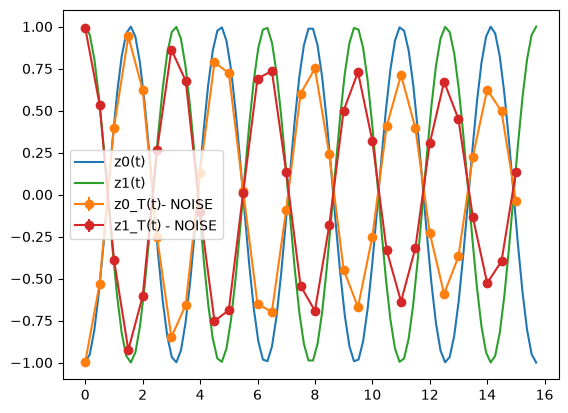

In [22]:
plt.plot(times,z0_oft,label="z0(t)")
plt.errorbar(tstep*np.arange(nsteps),z0_noise,yerr=ez0_noise,fmt='-o',label="z0_T(t)- NOISE")
plt.plot(times,z1_oft,label="z1(t)")
plt.errorbar(tstep*np.arange(nsteps),z1_noise,yerr=ez1_noise,fmt='-o',label="z1_T(t) - NOISE")
plt.legend()
plt.show()

The statistical errors are smaller than the size of the symbols (we used $100$k shots). There is a clear effect of decoherence

### RO mitigation

We can now try to mitigate the effect of read out errors as we learned in the previous class.

In [24]:
from error_mit import get_single_qubit_ro_probs, get_mit_counts, fix_negative

In [25]:
## extract calibration matrices
cal_matrices = get_single_qubit_ro_probs(counts_noise[0:2])

_Found 2 qubits in first calibration circuit counts


In [26]:
## obtain corrected counts
num_qubits = 2
mit_counts = []
for rc in counts_noise:
    mc = get_mit_counts(rc,num_qubits,cal_matrices)
    mit_counts.append(mc)

In [27]:
mit_counts[2]

{'00': np.float64(-16.23334534870408),
 '10': np.float64(1.1714409215112576),
 '01': np.float64(100025.31599748312),
 '11': np.float64(-10.25409305593189)}

In [28]:
## extract mitigated results
z0_noise_romit = np.zeros(nsteps)
ez0_noise_romit = np.zeros(nsteps)
z1_noise_romit = np.zeros(nsteps)
ez1_noise_romit = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    z0_noise_romit[count_idx], ez0_noise_romit[count_idx] = exp_err_from_counts(mit_counts[2+count_idx],[0])
    z1_noise_romit[count_idx], ez1_noise_romit[count_idx] = exp_err_from_counts(mit_counts[2+count_idx],[1])

/tmp/ipykernel_2161687/423019566.py:20: RuntimeWarning: invalid value encountered in sqrt
  err_obs = np.sqrt((1-average_obs**2)/(tot_counts-1))


Negative counts are creating problems with the error estimate. We can fix them with the procedure we saw before

In [29]:
## extract mitigated results
z0_noise_romit = np.zeros(nsteps)
ez0_noise_romit = np.zeros(nsteps)
z1_noise_romit = np.zeros(nsteps)
ez1_noise_romit = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    z0_noise_romit[count_idx], ez0_noise_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+count_idx]),[0])
    z1_noise_romit[count_idx], ez1_noise_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+count_idx]),[1])

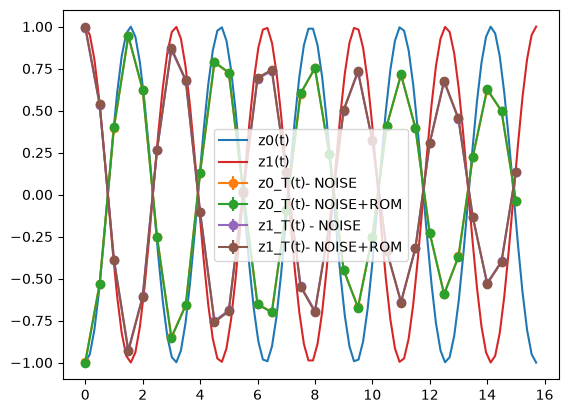

In [30]:
plt.plot(times,z0_oft,label="z0(t)")
plt.errorbar(tstep*np.arange(nsteps),z0_noise,yerr=ez0_noise,fmt='-o',label="z0_T(t)- NOISE")
plt.errorbar(tstep*np.arange(nsteps),z0_noise_romit,yerr=ez0_noise_romit,fmt='-o',label="z0_T(t)- NOISE+ROM")
plt.plot(times,z1_oft,label="z1(t)")
plt.errorbar(tstep*np.arange(nsteps),z1_noise,yerr=ez1_noise,fmt='-o',label="z1_T(t) - NOISE")
plt.errorbar(tstep*np.arange(nsteps),z1_noise_romit,yerr=ez1_noise_romit,fmt='-o',label="z1_T(t)- NOISE+ROM")
plt.legend()
plt.show()

As expected, the role of read-out errors is marginal with this noise model.

### Decoherence mitigation

We can attempt to mitigate the effect of gate error by assuming a global depolarizing noise channel and using the fact that $Z_0Z_1$ is a conserved Pauli operator.

In [31]:
##
z0z1_oft_trott = np.zeros(nsteps)
psit_now = initial_state
for tidx in range(nsteps):
    # measure current expectation values
    z0z1_oft_trott[tidx] = np.real(np.vdot(psit_now,Z_0Z_1@psit_now))
    # make a step
    psit_now = trott_step@psit_now
z0z1_oft_trott

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1.])

In [32]:
## extract mitigated results
z0z1_noise_romit = np.zeros(nsteps)
ez0z1_noise_romit = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    z0z1_noise_romit[count_idx], ez0z1_noise_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+count_idx]),[0,1])

In [33]:
z0z1_noise_romit

array([-1.        , -0.98673976, -0.97192721, -0.95034285, -0.93549218,
       -0.92104545, -0.90993349, -0.90093649, -0.88460836, -0.87108266,
       -0.85147753, -0.83830662, -0.82884841, -0.81903393, -0.80523932,
       -0.79011674, -0.77606839, -0.76251347, -0.75428937, -0.7453677 ,
       -0.73244401, -0.72120879, -0.70782603, -0.6930365 , -0.68336034,
       -0.67636854, -0.66514525, -0.65432839, -0.63692359, -0.62841736,
       -0.62424377])

We can then plot the error probability as a function of the time, which is linearly increasing with depth

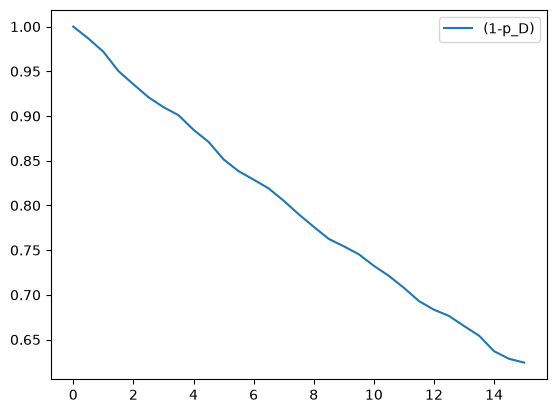

In [34]:
dep_factor = z0z1_noise_romit/z0z1_oft_trott
plt.plot(tstep*np.arange(nsteps),dep_factor,label='(1-p_D)')
plt.legend()
plt.show()

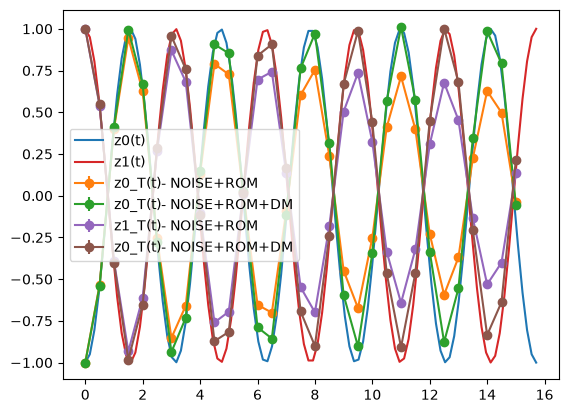

In [35]:
plt.plot(times,z0_oft,label="z0(t)")
plt.errorbar(tstep*np.arange(nsteps),z0_noise_romit,yerr=ez0_noise_romit,fmt='-o',label="z0_T(t)- NOISE+ROM")
plt.errorbar(tstep*np.arange(nsteps),z0_noise_romit/dep_factor,yerr=ez0_noise_romit/dep_factor,fmt='-o',label="z0_T(t)- NOISE+ROM+DM")
plt.plot(times,z1_oft,label="z1(t)")
plt.errorbar(tstep*np.arange(nsteps),z1_noise_romit,yerr=ez1_noise_romit,fmt='-o',label="z1_T(t)- NOISE+ROM")
plt.errorbar(tstep*np.arange(nsteps),z1_noise_romit/dep_factor,yerr=ez1_noise_romit/dep_factor,fmt='-o',label="z0_T(t)- NOISE+ROM+DM")
plt.legend()
plt.show()

This procedure worked remarkably well in this case but in general:

- the assumption that the error can be approximated well by a global depolarizing channel might not hold
- we might not have a simple way to mesaure a conserved Pauli together with our observables

A better strategy is to run, together with our intended circuits, also a set of circuits which are as close as possible to the ones we want but for which we do know the ideal expectation values. There are different strategies to achieve this

- we keep the circuit the same but use a different initial state whose evolution is simple (not always possible)
- we approximate the circuit with a simpler one that we can simulate efficiently (using e.g. only Clifford gates)
- we modifiy the circuit keeping the same building blocks but ensuring that after modification the simulation is simple

A common strategy to perform the last one when studying time-evolution is to consider circuits with an even number of time-steps and reverse the time parameter for the second half. When using a second order Trotter decomposition this can be done also at the level of individual steps.

In [36]:
## Reverse Trotter step
rev_trott_step_c = QuantumCircuit(2)
## z evolution for half step
rev_trott_step_c.rz(-tstep,[0,1])
## xx evolution for full step
rev_trott_step_c.h([0,1])
rev_trott_step_c.cx(0,1)
rev_trott_step_c.rz(-2*tstep,1)
rev_trott_step_c.cx(0,1)
rev_trott_step_c.h([0,1])
## z evolution for half step
rev_trott_step_c.rz(-tstep,[0,1])
## barrier to prevent unwanted optimizations
rev_trott_step_c.barrier()

## Idle step
## Reverse Trotter step
idle_trott_step_c = QuantumCircuit(2)
## z evolution for half step
idle_trott_step_c.rz(tstep,[0,1])
## xx evolution for full step
idle_trott_step_c.h([0,1])
idle_trott_step_c.cx(0,1)
idle_trott_step_c.rz(tstep,1)
## this is to prevent unwanted simplifications
idle_trott_step_c.barrier()
idle_trott_step_c.rz(-tstep,1)
idle_trott_step_c.cx(0,1)
idle_trott_step_c.h([0,1])
## z evolution for half step
idle_trott_step_c.rz(-tstep,[0,1])
## barrier to prevent unwanted optimizations
idle_trott_step_c.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [37]:
circuits_for_mit = []
## First we do wanted Trotter circuits
circuit_now = state_prep_c.copy()
for steps in range(nsteps):
    circuits_for_mit.append(circuit_now.copy())
    circuit_now.append(trott_step_c,[0,1])
## then we do Trotter circuits for mitigation
for steps in range(nsteps):
    circuit_now = state_prep_c.copy()
    ## the first steps//2 steps we move forward
    for ss in range(steps//2):
        circuit_now.append(trott_step_c,[0,1])
    ## for odd values of steps we need an idle one
    if steps%2:
        circuit_now.append(idle_trott_step_c,[0,1])
    ## the last steps//2 steps we move backward
    for ss in range(steps//2):
        circuit_now.append(rev_trott_step_c,[0,1])
    ## append final circuit to list
    circuits_for_mit.append(circuit_now.copy())
### we finish by transpiling everything
transpiled_circuits_for_mit = []
## first the RO calibration
for circ in cal_circuits_simple:
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=0,
                                initial_layout=[0,1]
                    )
    transpiled_circuits_for_mit.append(transpiled)
for circ in circuits_for_mit:
    # add final measurements in the computational basis
    ## NOTE: this modifies original circuit
    circ.measure_all()
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=1,
                                initial_layout=[0,1]
                    )
    transpiled_circuits_for_mit.append(transpiled)

In [38]:
noise_job_mit = sim_noisy.run(transpiled_circuits_for_mit,shots=100000,seed_simulator=21)
counts_noise_mit = noise_job_mit.result().get_counts()

As a first step we can look at the probability of measuring the '01' bit-string as a proxy for the noise strength.

In [39]:
## first without RO mitigation
p_dep = np.zeros(nsteps)
errp_dep = np.zeros(nsteps)
for ss in range(nsteps):
    current_counts = counts_noise_mit[2+nsteps+ss]
    nshots = sum([current_counts[kk] for kk in current_counts])
    p_01 = current_counts['01']/nshots
    p_dep[ss] = p_01
    errp_dep[ss] = np.sqrt(p_01*(1.-p_01)/nshots) 

In [40]:
## then with RO mitigation

## extract calibration matrices
cal_matrices = get_single_qubit_ro_probs(counts_noise_mit[0:2])
## obtain corrected counts
num_qubits = 2
mit_counts = []
for rc in counts_noise_mit:
    mc = get_mit_counts(rc,num_qubits,cal_matrices)
    mit_counts.append(mc)
## 
p_dep_rom = np.zeros(nsteps)
errp_dep_rom = np.zeros(nsteps)
for ss in range(nsteps):
    current_counts = fix_negative(mit_counts[2+nsteps+ss])
    nshots = sum([current_counts[kk] for kk in current_counts])
    p_01 = current_counts['01']/nshots
    p_dep_rom[ss] = p_01
    errp_dep_rom[ss] = np.sqrt(p_01*(1.-p_01)/nshots) 

_Found 2 qubits in first calibration circuit counts


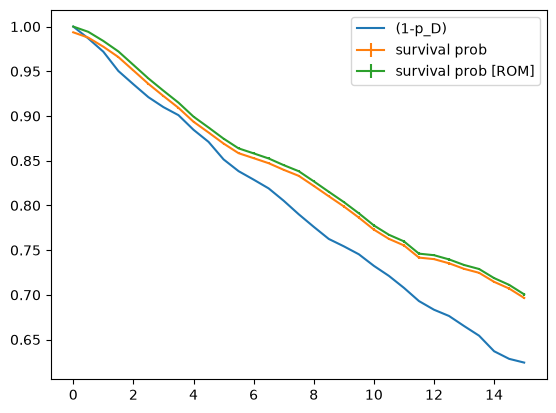

In [41]:
dep_factor = z0z1_noise_romit/z0z1_oft_trott
plt.plot(tstep*np.arange(nsteps),dep_factor,label='(1-p_D)')
plt.errorbar(tstep*np.arange(nsteps),p_dep,errp_dep,label='survival prob')
plt.errorbar(tstep*np.arange(nsteps),p_dep_rom,errp_dep_rom,label='survival prob [ROM]')
plt.legend()
plt.show()

We can also extract the individual error strength for every observable we want. For this we use only the results with RO already mitigated for simplicity but it is always a good practice to check the influence of the mitigation step to ensure with the data collected the procedure behaves as expected

In [42]:
## extract mitigated results
z0_noise_romit = np.zeros(nsteps)
ez0_noise_romit = np.zeros(nsteps)
z1_noise_romit = np.zeros(nsteps)
ez1_noise_romit = np.zeros(nsteps)
z0z1_noise_romit = np.zeros(nsteps)
ez0z1_noise_romit = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    z0_noise_romit[count_idx], ez0_noise_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+count_idx]),[0])
    z1_noise_romit[count_idx], ez1_noise_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+count_idx]),[1])
    z0z1_noise_romit[count_idx], ez0z1_noise_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+count_idx]),[0,1])

In [43]:
## extract mitigated results
z0_cal_romit = np.zeros(nsteps)
ez0_cal_romit = np.zeros(nsteps)
z1_cal_romit = np.zeros(nsteps)
ez1_cal_romit = np.zeros(nsteps)
z0z1_cal_romit = np.zeros(nsteps)
ez0z1_cal_romit = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    z0_cal_romit[count_idx], ez0_cal_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+nsteps+count_idx]),[0])
    z1_cal_romit[count_idx], ez1_cal_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+nsteps+count_idx]),[1])
    z0z1_cal_romit[count_idx], ez0z1_cal_romit[count_idx] = exp_err_from_counts(fix_negative(mit_counts[2+nsteps+count_idx]),[0,1])

In [44]:
dep_z0 = z0_cal_romit/(-1.)
dep_z1 = z1_cal_romit
dep_z0z1 = z0z1_cal_romit/(-1.)

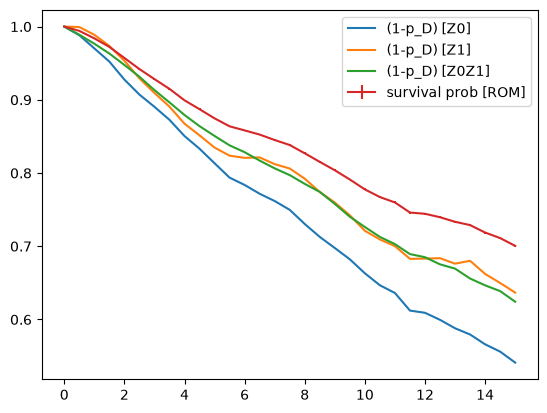

In [45]:
dep_factor = z0z1_noise_romit/z0z1_oft_trott
plt.plot(tstep*np.arange(nsteps),dep_z0,label='(1-p_D) [Z0]')
plt.plot(tstep*np.arange(nsteps),dep_z1,label='(1-p_D) [Z1]')
plt.plot(tstep*np.arange(nsteps),dep_z0z1,label='(1-p_D) [Z0Z1]')
plt.errorbar(tstep*np.arange(nsteps),p_dep_rom,errp_dep_rom,label='survival prob [ROM]')
plt.legend()
plt.show()

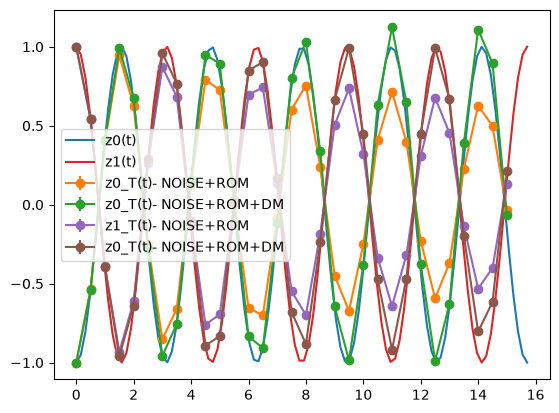

In [46]:
plt.plot(times,z0_oft,label="z0(t)")
plt.errorbar(tstep*np.arange(nsteps),z0_noise_romit,yerr=ez0_noise_romit,fmt='-o',label="z0_T(t)- NOISE+ROM")
plt.errorbar(tstep*np.arange(nsteps),z0_noise_romit/dep_z0,yerr=ez0_noise_romit/dep_z0,fmt='-o',label="z0_T(t)- NOISE+ROM+DM")
plt.plot(times,z1_oft,label="z1(t)")
plt.errorbar(tstep*np.arange(nsteps),z1_noise_romit,yerr=ez1_noise_romit,fmt='-o',label="z1_T(t)- NOISE+ROM")
plt.errorbar(tstep*np.arange(nsteps),z1_noise_romit/dep_z1,yerr=ez1_noise_romit/dep_z1,fmt='-o',label="z0_T(t)- NOISE+ROM+DM")
plt.legend()
plt.show()

Notice that the procedure works very well most of the time but some points have still large biases. This is mostly due to the fact that we are assuming the error to look like a global depolarizing channel but in reality, and even in qiskit noise models, there are also important coherent errors that our procedure is not able to properly characterize and mitigate.

One possible strategy, which works amazingly well in practice, is to randomize the compilation of our circuits using for instance Pauli Twirling. The average error channel is now dominantly incoherent and we can benefit more from our mitigation procedure.

Here we will use a custom transpile pass proposed in the qiskit documentation to add random Pauli gates around *cx* and *cz* gates to perform the twirling. We will now no longer use simply the *transpile* function but use instead a slightly more complex transpilation procedure

In [47]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

opt_level = 2
initial_layout = [0,1]

# define a pass manager for transpilation to keep it separate from the twirling one
pm = generate_preset_pass_manager(backend=fake_2qubits, 
                                      target=fake_2qubits.target, 
                                      optimization_level=opt_level, 
                                      initial_layout=initial_layout)

In [50]:
from twirl import PauliTwirl
from qiskit.transpiler import PassManager

twirl=PauliTwirl()
pm_twirl = PassManager([twirl])

In [51]:
circuits_for_mit = []
## First we do wanted Trotter circuits
circuit_now = state_prep_c.copy()
for steps in range(nsteps):
    circuits_for_mit.append(circuit_now.copy())
    circuit_now.append(trott_step_c,[0,1])
## then we do Trotter circuits for mitigation
for steps in range(nsteps):
    circuit_now = state_prep_c.copy()
    ## the first steps//2 steps we move forward
    for ss in range(steps//2):
        circuit_now.append(trott_step_c,[0,1])
    ## for odd values of steps we need an idle one
    if steps%2:
        circuit_now.append(idle_trott_step_c,[0,1])
    ## the last steps//2 steps we move backward
    for ss in range(steps//2):
        circuit_now.append(rev_trott_step_c,[0,1])
    ## append final circuit to list
    circuits_for_mit.append(circuit_now.copy())

In [52]:
num_twirls = 10
### we finish by transpiling everything
transpiled_circuits_for_mit = []
## first the RO calibration
for circ in cal_circuits_simple:
    transpiled = pm.run(circ)
    transpiled_circuits_for_mit.append(transpiled)
for circ in circuits_for_mit:
    # add final measurements in the computational basis
    ## NOTE: this modifies original circuit
    current_circuit = circ.copy()
    current_circuit.measure_all()
    for tt in range(num_twirls):
        circ_now = pm.run(current_circuit)
        circ_now = pm_twirl.run(circ_now)
        circ_now = pm.run(circ_now)
        transpiled_circuits_for_mit.append(circ_now)

In [53]:
noise_job_mit_tw = sim_noisy.run(transpiled_circuits_for_mit,shots=10000,seed_simulator=21)
counts_noise_mit_tw = noise_job_mit_tw.result().get_counts()

No we can either compute expectation values and average over the twirl samples after or more simply aggregate together all the different counts for twirls. For observables depending linearly on the counts there won't be any difference (statistical uncertainties might...).

Here we follow the simplest procedure and aggregate the different twirled counts

In [54]:
aggregated_counts = []
## the first two calibration runs get simply copied (we didn't twirl them)
aggregated_counts.append(counts_noise_mit_tw[0])
aggregated_counts.append(counts_noise_mit_tw[1])
## we now aggregate counts for the twirls
for ss in range(nsteps*2):
    counts_now = {}
    for tt in range(num_twirls):
        for kk in counts_noise_mit_tw[2+num_twirls*ss+tt]:
            if kk in counts_now:
                ## increment if present
                counts_now[kk] += counts_noise_mit_tw[2+num_twirls*ss+tt][kk]
            else:
                ## add new if not present
                counts_now[kk] = counts_noise_mit_tw[2+num_twirls*ss+tt][kk]
    aggregated_counts.append(counts_now)

In [55]:
## extract calibration matrices
cal_matrices = get_single_qubit_ro_probs(aggregated_counts[0:2])
## obtain corrected counts
num_qubits = 2
mit_counts_tw = []
for rc in aggregated_counts:
    mc = get_mit_counts(rc,num_qubits,cal_matrices)
    mit_counts_tw.append(mc)

_Found 2 qubits in first calibration circuit counts


In [56]:
## extract mitigated results
z0_cal_romit_tw = np.zeros(nsteps)
ez0_cal_romit_tw = np.zeros(nsteps)
z1_cal_romit_tw = np.zeros(nsteps)
ez1_cal_romit_tw = np.zeros(nsteps)
z0z1_cal_romit_tw = np.zeros(nsteps)
ez0z1_cal_romit_tw = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    z0_cal_romit_tw[count_idx], ez0_cal_romit_tw[count_idx] = exp_err_from_counts(fix_negative(mit_counts_tw[2+nsteps+count_idx]),[0])
    z1_cal_romit_tw[count_idx], ez1_cal_romit_tw[count_idx] = exp_err_from_counts(fix_negative(mit_counts_tw[2+nsteps+count_idx]),[1])
    z0z1_cal_romit_tw[count_idx], ez0z1_cal_romit_tw[count_idx] = exp_err_from_counts(fix_negative(mit_counts_tw[2+nsteps+count_idx]),[0,1])

In [57]:
dep_z0_tw = z0_cal_romit_tw/(-1.)
dep_z1_tw = z1_cal_romit_tw
dep_z0z1_tw = z0z1_cal_romit_tw/(-1.)

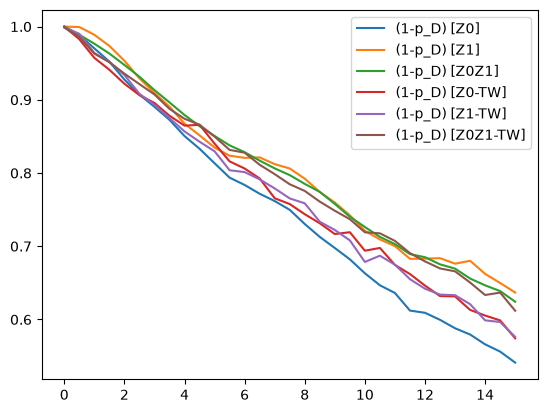

In [58]:
plt.plot(tstep*np.arange(nsteps),dep_z0,label='(1-p_D) [Z0]')
plt.plot(tstep*np.arange(nsteps),dep_z1,label='(1-p_D) [Z1]')
plt.plot(tstep*np.arange(nsteps),dep_z0z1,label='(1-p_D) [Z0Z1]')
plt.plot(tstep*np.arange(nsteps),dep_z0_tw,label='(1-p_D) [Z0-TW]')
plt.plot(tstep*np.arange(nsteps),dep_z1_tw,label='(1-p_D) [Z1-TW]')
plt.plot(tstep*np.arange(nsteps),dep_z0z1_tw,label='(1-p_D) [Z0Z1-TW]')
plt.legend()
plt.show()

In [59]:
## extract mitigated results
z0_noise_romit_tw = np.zeros(nsteps)
ez0_noise_romit_tw = np.zeros(nsteps)
z1_noise_romit_tw = np.zeros(nsteps)
ez1_noise_romit_tw = np.zeros(nsteps)
z0z1_noise_romit_tw = np.zeros(nsteps)
ez0z1_noise_romit_tw = np.zeros(nsteps)

for count_idx in range(nsteps):
    ##NOTE skip first two calibration runs
    z0_noise_romit_tw[count_idx], ez0_noise_romit_tw[count_idx] = exp_err_from_counts(fix_negative(mit_counts_tw[2+count_idx]),[0])
    z1_noise_romit_tw[count_idx], ez1_noise_romit_tw[count_idx] = exp_err_from_counts(fix_negative(mit_counts_tw[2+count_idx]),[1])
    z0z1_noise_romit_tw[count_idx], ez0z1_noise_romit_tw[count_idx] = exp_err_from_counts(fix_negative(mit_counts_tw[2+count_idx]),[0,1])

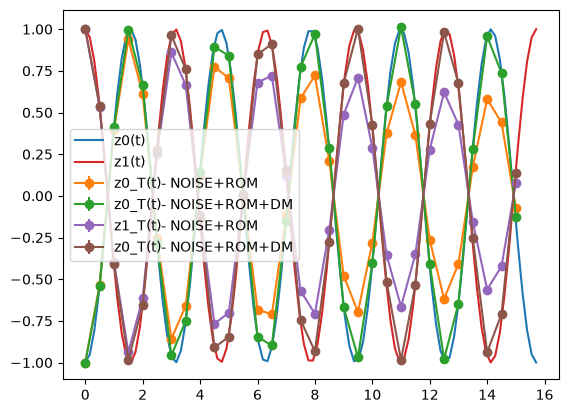

In [60]:
plt.plot(times,z0_oft,label="z0(t)")
plt.errorbar(tstep*np.arange(nsteps),z0_noise_romit_tw,yerr=ez0_noise_romit_tw,fmt='-o',label="z0_T(t)- NOISE+ROM")
plt.errorbar(tstep*np.arange(nsteps),z0_noise_romit_tw/dep_z0_tw,yerr=ez0_noise_romit_tw/dep_z0_tw,fmt='-o',label="z0_T(t)- NOISE+ROM+DM")
plt.plot(times,z1_oft,label="z1(t)")
plt.errorbar(tstep*np.arange(nsteps),z1_noise_romit_tw,yerr=ez1_noise_romit_tw,fmt='-o',label="z1_T(t)- NOISE+ROM")
plt.errorbar(tstep*np.arange(nsteps),z1_noise_romit_tw/dep_z1_tw,yerr=ez1_noise_romit_tw/dep_z1_tw,fmt='-o',label="z0_T(t)- NOISE+ROM+DM")
plt.legend()
plt.show()

The mitigated results are now essentially exact, as we were hoping.

### Examples on real hardware

...coming soon...